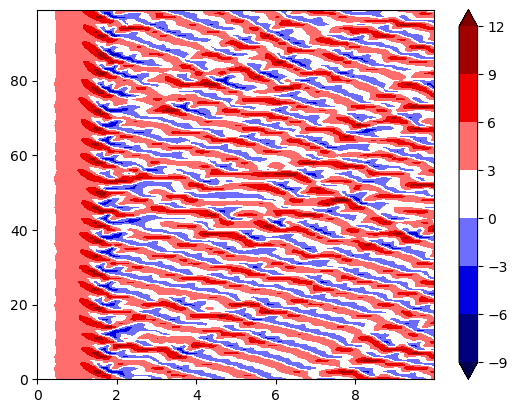

In [10]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


import numpy as np
import matplotlib.pyplot as plt

F = 8
N = 100
T = 10
dt = 0.01
grid = np.arange(0,N)
time = np.arange(0,T,dt)
X = np.random.normal(0,0.1,size=N)
x_history = []

for t in time:
    dxdt = np.zeros(N)
    for i in range(N):
        dxdt = X[(i - 1) % N] * (X[(i + 1) % N] - X[(i - 2) % N]) - X[i] + F
        X[i] = X[i] + dxdt * dt
        x_history.append(X[i])
x_history = np.array(x_history)
x_history = x_history.reshape(1000,100)

xx, yy = np.meshgrid(grid,time)
CS = plt.contourf(yy,xx, x_history, cmap='seismic',extend='both')
plt.colorbar(CS, orientation='vertical')
plt.show()



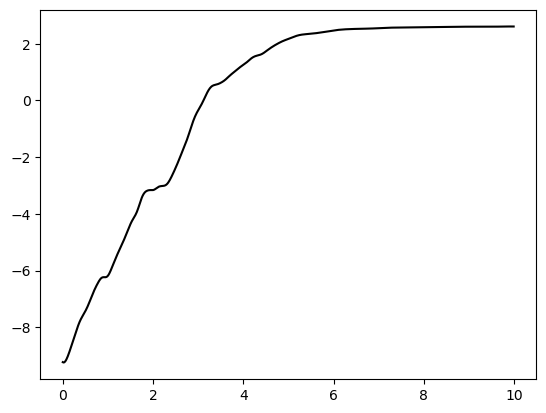

In [11]:
import numpy as np
import matplotlib.pyplot as plt

F = 8
N = 100
T = 10
dt = 0.01
grid = np.arange(0, N)
time = np.arange(0, T, dt)
simulation = []

for s in range(500): # ensemble
    X = x_history[600,:] + np.random.normal(0,1e-2,size=N)
    x_history2= []  
    for t in time:
        dxdt = np.zeros(N)
        for i in range(N):
            dxdt[i] = X[(i - 1) % N] * (X[(i + 1) % N] - X[(i - 2) % N]) - X[i] + F
            X[i] = X[i] + dxdt[i] * dt
            x_history2.append(X[i])
    x_history2 = np.array(x_history2)
    x_history2 = x_history2.reshape(1000, 100)
    simulation.append(x_history2)

variance_simulation = (np.var(simulation, axis=0))
variance_simulation = np.mean(variance_simulation,axis=1)
plt.plot(time,np.log(variance_simulation),'k-')
plt.show()



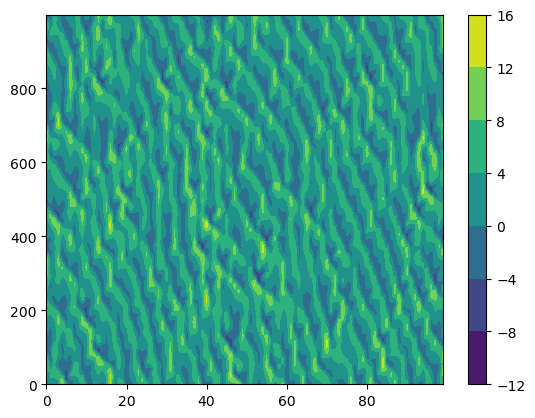

In [9]:
cs=plt.contourf(np.array(simulation)[1,:,:])
plt.colorbar(cs)